In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymongo

In [27]:
df = pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [28]:
data = df.to_dict(orient="records")
# data

In [29]:
DB_NAME = "Vehical_Insurance"
COLLECTION_NAME = "Vehical_Insurance_Data"
CONNECTION_URL = "mongodb://localhost:27017"

In [30]:
client = pymongo.MongoClient(CONNECTION_URL)
data_base = client[DB_NAME]
collection = data_base[COLLECTION_NAME]

In [31]:
# Uploading data to MongoDB
rec = collection.insert_many(data)

In [32]:
# for doc in collection.find():
#     print(doc)

In [33]:
# Load back data from mongodb

df = pd.DataFrame(list(collection.find()))
df.head()

,_id,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,69e668e1419d59e36f1a5f0d,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,69e668e1419d59e36f1a5f0e,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,69e668e1419d59e36f1a5f0f,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,69e668e1419d59e36f1a5f10,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,69e668e1419d59e36f1a5f11,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


### EDA

In [34]:
df.shape

(3048872, 13)

In [35]:
df.isnull().sum()

_id                     0
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3048872 entries, 0 to 3048871
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   _id                   object 
 1   id                    int64  
 2   Gender                object 
 3   Age                   int64  
 4   Driving_License       int64  
 5   Region_Code           float64
 6   Previously_Insured    int64  
 7   Vehicle_Age           object 
 8   Vehicle_Damage        object 
 9   Annual_Premium        float64
 10  Policy_Sales_Channel  float64
 11  Vintage               int64  
 12  Response              int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 302.4+ MB


In [37]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,3.048872e+06,3.048872e+06,3.048872e+06,3.048872e+06,3.048872e+06,3.048872e+06,3.048872e+06,3.048872e+06,3.048872e+06
mean,1.905550e+05,3.882258e+01,9.978694e-01,2.638881e+01,4.582101e-01,3.056439e+04,1.120343e+02,1.543474e+02,1.225634e-01
std,1.100167e+05,1.551159e+01,4.610949e-02,1.322987e+01,4.982506e-01,1.721314e+04,5.420393e+01,8.367121e+01,3.279354e-01
min,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.630000e+03,1.000000e+00,1.000000e+01,0.000000e+00
25%,9.527800e+04,2.500000e+01,1.000000e+00,1.500000e+01,0.000000e+00,2.440500e+04,2.900000e+01,8.200000e+01,0.000000e+00
50%,1.905550e+05,3.600000e+01,1.000000e+00,2.800000e+01,0.000000e+00,3.166900e+04,1.330000e+02,1.540000e+02,0.000000e+00
75%,2.858320e+05,4.900000e+01,1.000000e+00,3.500000e+01,1.000000e+00,3.940000e+04,1.520000e+02,2.270000e+02,0.000000e+00
max,3.811090e+05,8.500000e+01,1.000000e+00,5.200000e+01,1.000000e+00,5.401650e+05,1.630000e+02,2.990000e+02,1.000000e+00


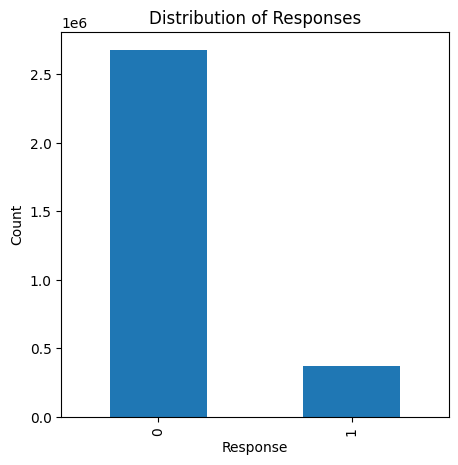

In [38]:
value_counts = df['Response'].value_counts()

plt.figure(figsize=(5, 5))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Responses')

# Show the plot
plt.show()

<Axes: >

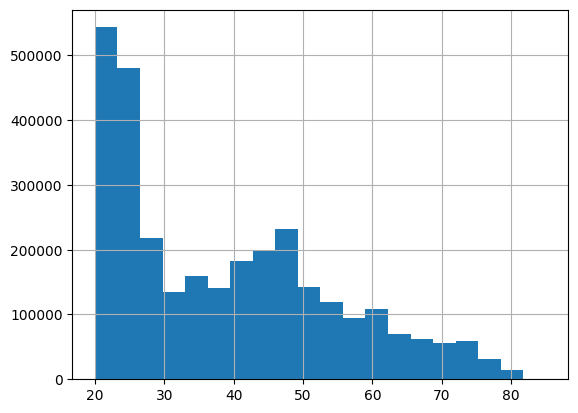

In [39]:
df['Age'].hist(bins=20)

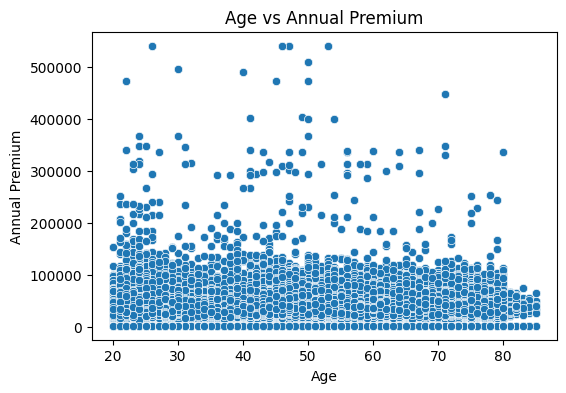

In [40]:
# Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='Annual_Premium', data=df)
plt.title('Age vs Annual Premium')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.show()

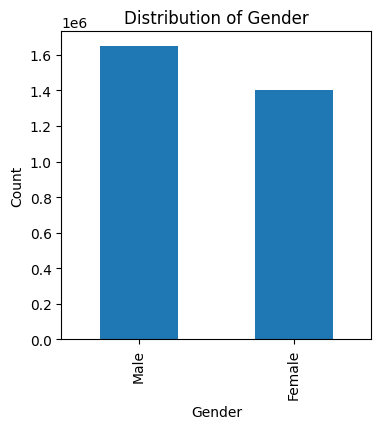

In [41]:
value_counts = df['Gender'].value_counts()
plt.figure(figsize=(4, 4))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')

# Show the plot
plt.show()

### Data Preprocessing

In [42]:
num_feat = ['Age','Vintage']
cat_feat = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age_lt_1_Year',
'Vehicle_Age_gt_2_Years','Vehicle_Damage_Yes','Region_Code','Policy_Sales_Channel']

In [43]:
df = df.drop(columns=["_id"])
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [44]:
df['Gender'] = df['Gender'].map({ 'Female': 0, 'Male': 1 }).astype('int')
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [45]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int64
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Vehicle_Age >> object
Vehicle_Damage >> object
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64


In [46]:
cat_cols = ["Vehicle_Age", "Vehicle_Damage"]

for col in cat_cols:
    df[col] = df[col].astype("category")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [47]:
df = pd.get_dummies(df, drop_first=True, sparse=True)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,1,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,1,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,0,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [48]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# cat_cols = ["Vehicle_Age", "Vehicle_Damage"]
# num_cols = [col for col in df.columns if col not in cat_cols + ["Response"]]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("cat", OneHotEncoder(drop="first", sparse_output=True), cat_cols),
#         ("num", "passthrough", num_cols)
#     ]
# )

In [49]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int64
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64
Vehicle_Age_< 1 Year >> Sparse[bool, False]
Vehicle_Age_> 2 Years >> Sparse[bool, False]
Vehicle_Damage_Yes >> Sparse[bool, False]


In [50]:
# cols renaming and keeping dtype as int

df = df.rename(columns={"Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year", "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"})

df['Vehicle_Age_lt_1_Year'] = df['Vehicle_Age_lt_1_Year'].astype('int')
df['Vehicle_Age_gt_2_Years'] = df['Vehicle_Age_gt_2_Years'].astype('int')
df['Vehicle_Damage_Yes'] = df['Vehicle_Damage_Yes'].astype('int')

In [51]:
for column in cat_feat:
    df[column] = df[column].astype('str')